In [ ]:
!kaggle datasets download shivam2503/diamonds

Dataset URL: https://www.kaggle.com/datasets/shivam2503/diamonds
License(s): unknown
100% 733k/733k [00:00<00:00, 1.66MB/s]



In [ ]:
!unzip diamonds.zip

Archive:  diamonds.zip
  inflating: diamonds.csv            


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('diamonds.csv')

In [ ]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [ ]:
df.duplicated().sum()

np.int64(0)

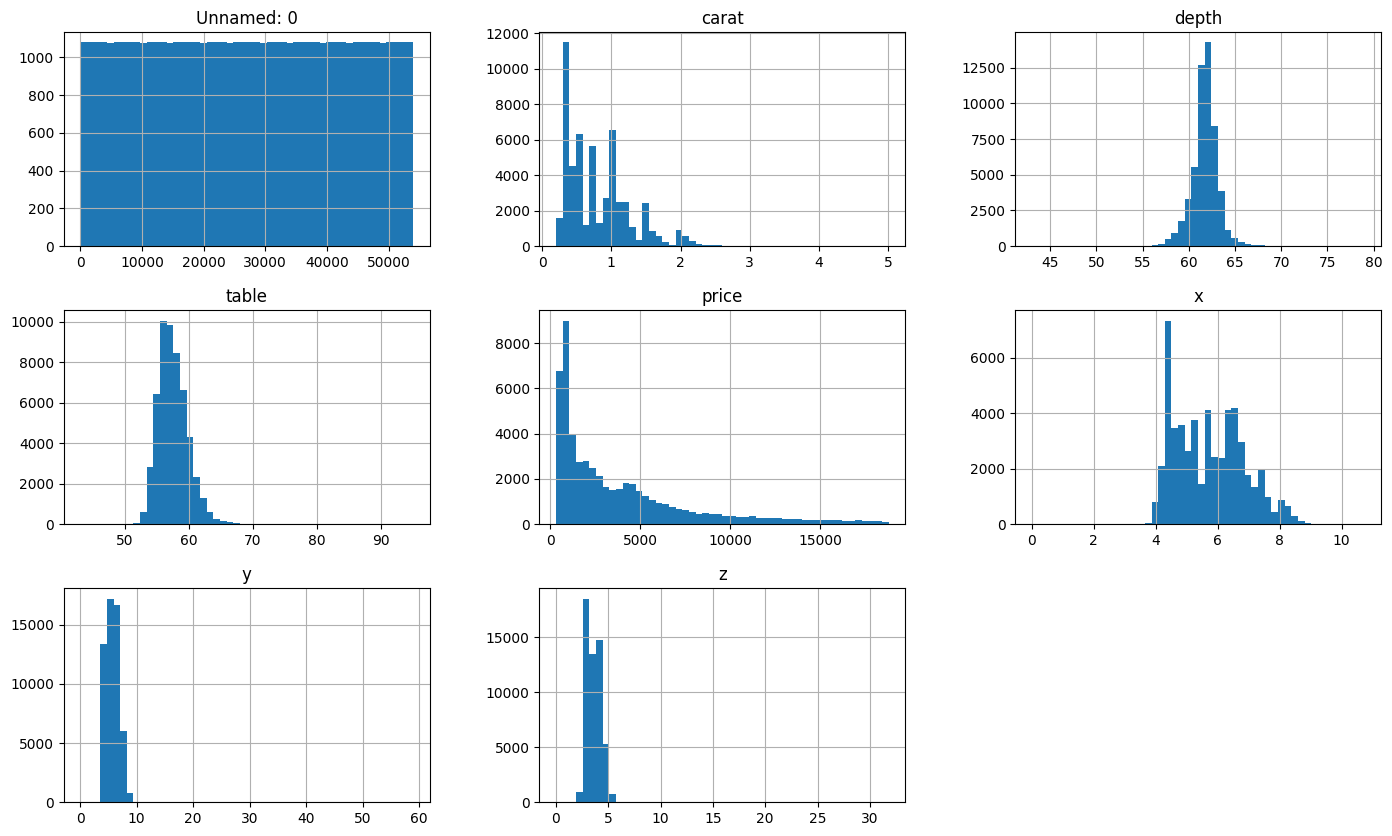

In [ ]:
df.hist(figsize=(17,10),bins=50);

In [ ]:
df.shape

(53940, 11)

In [ ]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

In [ ]:
df = df[~((df['price'] < (q1 - 1.5 * iqr)) |(df['price'] > (q3 + 1.5 * iqr)))]

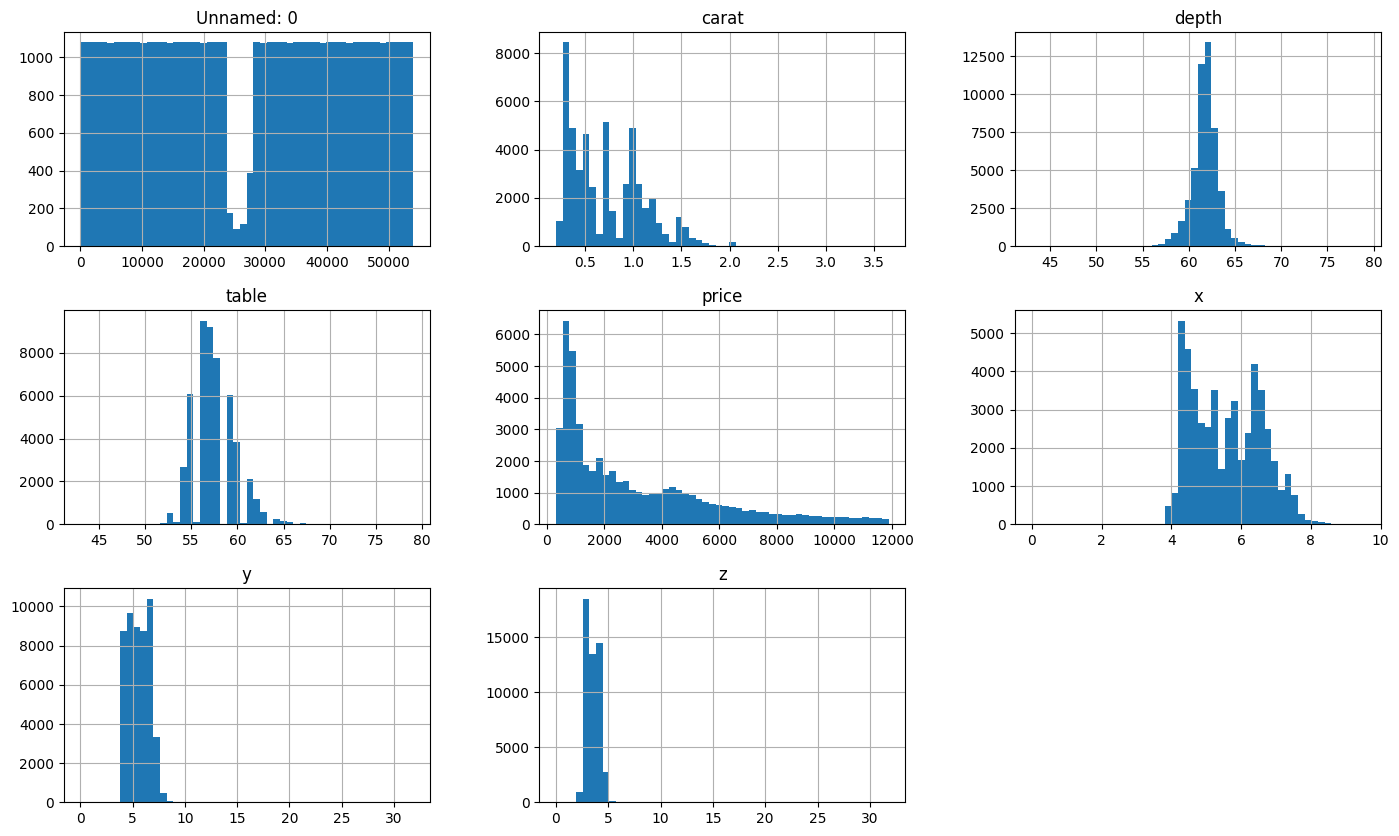

In [ ]:
df.hist(figsize=(17,10),bins=50);

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50400 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50400 non-null  int64  
 1   carat       50400 non-null  float64
 2   cut         50400 non-null  object 
 3   color       50400 non-null  object 
 4   clarity     50400 non-null  object 
 5   depth       50400 non-null  float64
 6   table       50400 non-null  float64
 7   price       50400 non-null  int64  
 8   x           50400 non-null  float64
 9   y           50400 non-null  float64
 10  z           50400 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.6+ MB


In [ ]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df['cut'].nunique()

5

In [ ]:
df['color'].nunique()

7

In [ ]:
df['clarity'].nunique()

8

In [ ]:
X = df.drop(columns= 'price')
y = df['price']

In [ ]:
import sklearn.model_selection as model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

num_cols = ['carat','depth','table']
cat_cols = ['cut','color','clarity']

num_pipeline = Pipeline([
	('scl', StandardScaler()),
])
cat_pipeline = Pipeline([
	('ohe', OneHotEncoder()),
])

preprocessing = ColumnTransformer([
	('NUM', num_pipeline, num_cols),
	('CAT', cat_pipeline, cat_cols)
], )

In [ ]:
full_pipeline = Pipeline([
	('prep', preprocessing),
	('model', LinearRegression()),
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred)

(548.5665381713249, 0.9167184663492579)

In [ ]:
full_pipeline = Pipeline([
	('prep', preprocessing),
	('model', LinearRegression()),
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred)

(548.5665381713249, 0.9167184663492579)

In [ ]:
full_pipeline = Pipeline([
	('prep', preprocessing),
	('model', SGDRegressor()),
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred)

(547.4714456883984, 0.9167465991100734)

In [ ]:
full_pipeline = Pipeline([
	('prep', preprocessing),
	('model', RandomForestRegressor()),
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred)

(217.0088646445039, 0.9809328220037333)

In [ ]:
full_pipeline.score(X_train,y_train),full_pipeline.score(X_test,y_test)

(0.996994563057453, 0.9809328220037333)